In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms #데이터 전처리를 위한 라이브러리
from torch.utils.data import Dataset, DataLoader

In [ ]:
#CPU 혹은 CPU 장치 확인
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
#데이터셋 내려받기
train_dataset = torchvision.datasets.FashionMNIST("../chap05/data", download = True,
                                                  transform = transforms.Compose([transforms.ToTensor()]))
test_dataset = torchvision.datasets.FashionMNIST("../chap05/data", download = True,
                                                 train = False, transform = transforms.Compose([transforms.ToTensor()]))
#transform은 이미지를 텐서(0~1)로 변경함

100%|██████████| 26.4M/26.4M [00:01<00:00, 16.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 254kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.01MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.21MB/s]


In [ ]:
#데이터를 데이터로더에 전달
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = 100)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = 100)
#데이터를 불러온 데이터셋 지정, 데이터를 배치로 묶어줌 (100개 단위로 묶어줌)

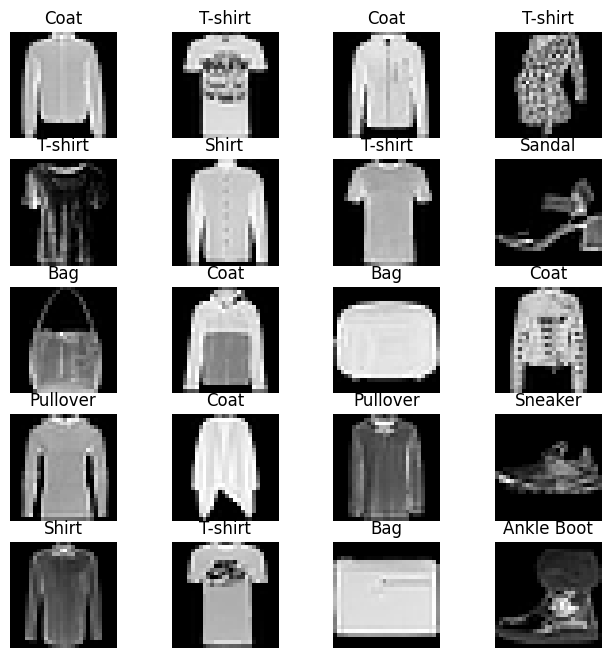

In [ ]:
#분류에 사용될 클래스 정의
labels_map = {0 : 'T-shirt', 1 : 'Trouser', 2 : 'Pullover', 3 : 'Dress', 4 : 'Coat',
              5 : 'Sandal', 6 : 'Shirt', 7 : 'Sneaker', 8 : 'Bag', 9 : 'Ankle Boot'}

#20개의 이미지 데이터를 시각적으로 표현
fig = plt.figure(figsize = (8, 8));
columns = 4;
rows = 5;
for i in range(1, columns * rows + 1):
  #이산형 분포를 갖는 데이터에서 무작위 표본을 추출
  #0~(train_dataset의 길이) 값을 갖는 분포에서 랜덤한 숫자 한 개를 생성
  img_xy = np.random.randint(len(train_dataset));
  #train_dataset을 이용한 3차원 배열 생성
  img = train_dataset[img_xy][0][0,:,:]
  fig.add_subplot(rows, columns, i)
  plt.title(labels_map[train_dataset[img_xy][1]])
  plt.axis('off')
  plt.imshow(img, cmap = 'gray')
plt.show()

In [ ]:
#심층 신경망 모델 생성
class FashionDNN(nn.Module): #class 형태의 모델은 항상 torch.nn.Module을 상속받음
  def __init__(self): #객체가 갖는 속성 값을 초기화하는 역할, 객체가 생성될 때 자동으로 호출
    super(FashionDNN, self).__init__() #FashionDNN이라는 부모 클래스를 상속받음
    #in_features = 입력의 크기, out_features = 출력의 크기
    #nn : 딥러닝 모델 구성에 필요한 모듈이 모여 있는 패키지, Linear는 단순 선형 회귀 모델을 만들 때 사용
    self.fc1 = nn.Linear(in_features = 784, out_features = 256)
    self.drop = nn.Dropout(0.25) #0.25만큼 비율로 텐서의 값이 0이 됨, 0이 되지 않는 값들은 커짐
    self.fc2 = nn.Linear(in_features = 256, out_features = 128)
    self.fc3 = nn.Linear(in_features = 128, out_features = 10)

  def forward(self, input_data): #순전파 학습을 진행, 객체를 데이터와 함께 호출하면 자동으로 실행됨
    #view는 넘파이의 reshape과 같은 역할로 텐서의 크기를 변경
    #input_data를 (-1, 784)의 크기로 변경, -1의 값은 직접 계산해야함
    out = input_data.view(-1, 784)
    #활성화 함수는 __init__, forward 둘 다에서 정의 가능
    out = F.relu(self.fc1(out))
    out = self.drop(out)
    out = F.relu(self.fc2(out))
    out = self.fc3(out)
    return out

In [ ]:
#심층 신경망에서 필요한 파라미터 정의
learning_rate = 0.001;
model = FashionDNN();
model.to(device)

criterion = nn.CrossEntropyLoss();
#optimizer을 위한 경사 하강법은 Adam 사용, 학습률은 0.001 사용
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate);
print(model)

FashionDNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


In [ ]:
#심층 신경망을 이용한 모델 학습
num_epochs = 5
count = 0

loss_list = []
iteration_list = []
accuracy_list = []

predictions_list = []
labels_list = []

for epoch in range(num_epochs):
  for images, labels in train_loader:
    #모델이 데이터를 처리하기 위해 모델과 데이터가 동일한 장치에 있어야 함
    images, labels = images.to(device), labels.to(device)

    #Autograd로 자동 미분된 값을 저장하기 위해 tape 사용
    #순전파에서 tape는 수행하는 모든 연산을 저장, 역전파에서 저장된 값들을 꺼내서 사용
    #Autograd는 Variable을 사용해서 역전파를 위한 미분 값을 자동으로 계산
    train = Variable(images.view(100, 1, 28, 28))
    labels = Variable(labels)

    outputs = model(train)
    loss = criterion(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    count += 1

    if not (count % 50): #count를 50으로 나누었을 때 나머지가 0이 아니면 실행
      total = 0
      correct = 0
      for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        labels_list.append(labels)
        test = Variable(images.view(100, 1, 28, 28))
        outputs = model(test)
        predictions = torch.max(outputs, 1)[1].to(device)
        predictions_list.append(predictions)
        correct += (predictions == labels).sum()
        total += len(labels)

      accuracy = correct * 100 / total
      loss_list.append(loss.data)
      iteration_list.append(count)
      accuracy_list.append(accuracy)

    if not (count % 500):
      print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))


Iteration: 500, Loss: 0.5912195444107056, Accuracy: 83.7300033569336%
Iteration: 1000, Loss: 0.42913830280303955, Accuracy: 85.06999969482422%
Iteration: 1500, Loss: 0.33972546458244324, Accuracy: 83.86000061035156%
Iteration: 2000, Loss: 0.42390331625938416, Accuracy: 84.97000122070312%
Iteration: 2500, Loss: 0.28261277079582214, Accuracy: 86.0199966430664%
Iteration: 3000, Loss: 0.2839193046092987, Accuracy: 85.86000061035156%


In [ ]:
#합성곱 네트워크 생성
class FashionCNN(nn.Module):
  def __init__(self):
    super(FashionCNN, self).__init__()
    #nn.Sequential()은 계층을 차례로 쌓을 수 있도록 wx + b와 같은 수식과 활성화 함수를 연결해주는 역할
    #여러 개의 계층을 하나의 컨테이너에 구현하는 방법
    self.layer1 = nn.Sequential(
        #(입력 채널의 수, 출력 채널의 수, 필터 크기, 출력 크기를 조정하기 위해 주위에 0으로 채움)
        nn.Conv2d(in_channels = 1, out_channels = 32, kernel_size = 3, padding = 1), #패딩 값이 클수록 출력 크기도 커짐
        nn.BatchNorm2d(32), #각 배치 단위별로 데이터가 다양한 분포를 가져도 평균과 분산을 이용하여 정규화함
        nn.ReLU(),
        #이미지 크기를 축소시키는 용도
        #(m*n 행렬로 구성된 가중치, 이동할 간격)
        nn.MaxPool2d(kernel_size = 2, stride = 2) #스트라이드 값이 커지면 출력 크기는 작아짐
    )
    self.layer2 = nn.Sequential(
        nn.Conv2d(in_channels = 32, out_channels = 64, kernel_size = 3),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    #클래스를 분류하기 위해 이미지 형태의 데이터를 배열 형태로 변환하여 작업
    #Conv2d에서 사용하는 하이퍼파라미터 값들에 따라 출력 크기가 달라짐
    self.fc1 = nn.Linear(in_features = 64*6*6, out_features = 600)
    self.drop = nn.Dropout2d(0.25)
    self.fc2 = nn.Linear(in_features = 600, out_features = 120)
    self.fc3 = nn.Linear(in_features = 120, out_features = 10) #마지막 계층의 out_features는 클래수 개수

  def forward(self, x):
    out = self.layer1(x)
    out = self.layer2(out)
    #합성곱층에서 완전 연결층으로 변경되기 때문에 데이터의 형태를 1차원으로 바꿔줌
    out = out.view(out.size(0), -1) #out.size(0)은 100을 의미 -> (100, ?) 크기의 텐서로 변경
    out = self.fc1(out)
    out = self.drop(out)
    out = self.fc2(out)
    out = self.fc3(out)
    return out

In [ ]:
#합성곱 네트워크를 위한 파라미터 정의
learning_rate = 0.001;
model = FashionCNN();
model.to(device)

criterion = nn.CrossEntropyLoss();
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate);
print(model)

FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=600, bias=True)
  (drop): Dropout2d(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
)


In [ ]:
#모델 학습 및 성능 평가
num_epochs = 5
count = 0
loss_list = []
iteration_list = []
accuracy_list = []

predictions_list = []
labels_list = []

for epoch in range(num_epochs):
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    train = Variable(images.view(100, 1, 28, 28))
    labels = Variable(labels)

    outputs = model(train)
    loss = criterion(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    count += 1

    if not (count % 50):
      total = 0
      correct = 0
      for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        labels_list.append(labels)
        test = Variable(images.view(100, 1, 28, 28))
        outputs = model(test)
        predictions = torch.max(outputs, 1)[1].to(device)
        predictions_list.append(predictions)
        correct += (predictions == labels).sum()
        total += len(labels)

      accuracy = correct * 100 / total
      loss_list.append(loss.data)
      iteration_list.append(count)
      accuracy_list.append(accuracy)

    if not (count % 500):
      print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))


Iteration: 500, Loss: 0.45545855164527893, Accuracy: 87.88999938964844%
Iteration: 1000, Loss: 0.31720197200775146, Accuracy: 88.91000366210938%
Iteration: 1500, Loss: 0.3124687075614929, Accuracy: 88.56999969482422%
Iteration: 2000, Loss: 0.21635320782661438, Accuracy: 89.58999633789062%
Iteration: 2500, Loss: 0.10785746574401855, Accuracy: 89.62999725341797%
Iteration: 3000, Loss: 0.17871271073818207, Accuracy: 90.58000183105469%
